# Explainable Deep Learning for Antimicrobial Resistance Prediction

## Stage 2: Data Exploration

## Dataset Overview

Dataset Name: DIBaS Microbial Image Dataset

Objective:
To explore microbial species images and understand dataset characteristics before building deep learning models.

## Dataset Statistics

- Total Classes: 33
- Total Images: 692
- Image Format: TIFF (.tif)
- Image Mode: RGB
- Image Resolution: 2048 × 1532

## Class Distribution

Observation:

- Dataset contains 33 microbial species.
- Most classes contain between 20 and 23 images.
- Dataset is relatively balanced.
- No severe class imbalance observed.

## Image Resolution Analysis

Observation:

- All valid images have resolution 2048 × 1532.
- Dataset is highly standardized.
- No resizing inconsistency observed.

## Blur Analysis

Results:

- Total Images Checked: 669
- Average Blur Score: 22.54
- Minimum Blur Score: 6.52
- Maximum Blur Score: 97.61

## Noise Analysis

Results:

- Total Images Checked: 669
- Average Noise Score: 26.62
- Minimum Noise Score: 5.80
- Maximum Noise Score: 65.77

## Corrupted Images

Three corrupted TIFF images were detected:

1. Micrococcus.spp_0023.tif
2. Micrococcus.spp_0021.tif
3. Listeria.monocytogenes_0023.tif

These files were excluded from image quality analysis.

## Sample Image Visualization

Objective:

To visually inspect microbial images from different species.

Observation:

Different microbial species exhibit unique visual patterns and textures which may help deep learning models learn discriminative features.

## Conclusion

The dataset contains 33 microbial species and 692 images.

Images are RGB format with consistent resolution (2048 × 1532).

The dataset is balanced across classes and suitable for microbial image classification tasks.

Only three corrupted images were detected during exploration.

Overall, the dataset is ready for preprocessing and deep learning model development.

# Stage 3: Dataset Visualization

Project:
Explainable Deep Learning for Antimicrobial Resistance Prediction

Objective:
Visualize and understand the microbial image dataset before preprocessing and model training.

# Class Distribution Visualization


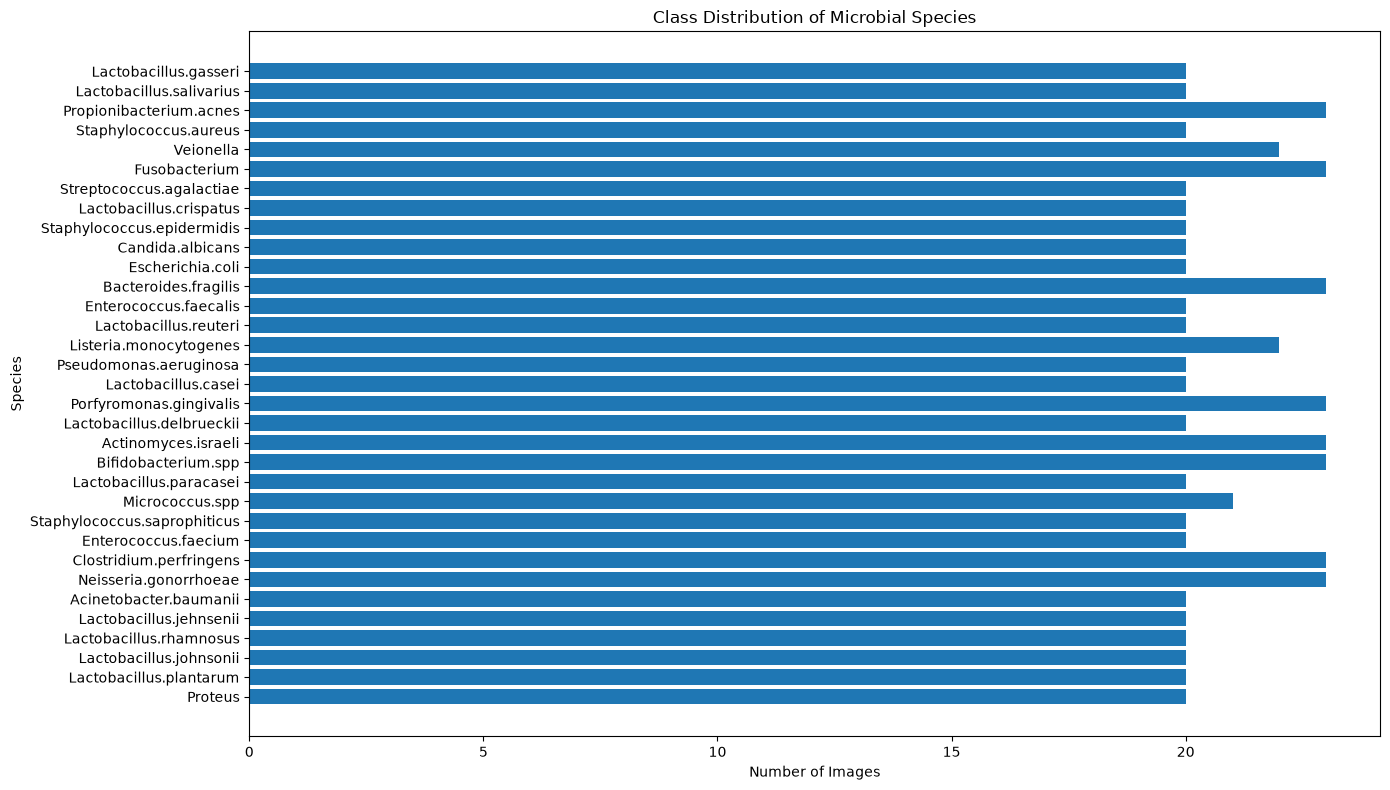

Graph saved successfully.
Total Classes: 33
Total Images : 689


In [3]:
# ============================================================
# Stage 3: Class Distribution Visualization
#
# Purpose:
# Visualize the number of images available for each
# microbial species in the dataset.
# ============================================================

# Import required libraries
import os
import matplotlib.pyplot as plt

# Dataset folder path
# Notebook is inside Notebook/ folder,
# so we go one level up using ..
dataset_path = "../archive"

# Store species names
species_names = []

# Store image counts
image_counts = []

# Loop through every species folder
for species in os.listdir(dataset_path):

    # Create complete species folder path
    species_path = os.path.join(dataset_path, species)

    # Skip if item is not a folder
    if not os.path.isdir(species_path):
        continue

    # Initialize image counter
    count = 0

    # Traverse folder recursively
    # This also handles nested folders
    for root, dirs, files in os.walk(species_path):

        # Check every file
        for file in files:

            # Count only TIFF images
            if file.lower().endswith(".tif"):
                count += 1

    # Store species name
    species_names.append(species)

    # Store image count
    image_counts.append(count)

# Create figure
plt.figure(figsize=(14, 8))

# Create horizontal bar chart
plt.barh(species_names, image_counts)

# Add chart title
plt.title("Class Distribution of Microbial Species")

# Add x-axis label
plt.xlabel("Number of Images")

# Add y-axis label
plt.ylabel("Species")

# Improve spacing
plt.tight_layout()

# Save graph in project results folder
plt.savefig(
    "../results/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Display graph
plt.show()

# Print success message
print("Graph saved successfully.")

# Print dataset summary
print("Total Classes:", len(species_names))
print("Total Images :", sum(image_counts))

Observation:

Most species contain between 20 and 23 images.

The dataset is balanced with minimal class imbalance.

# Sample Image Visualization

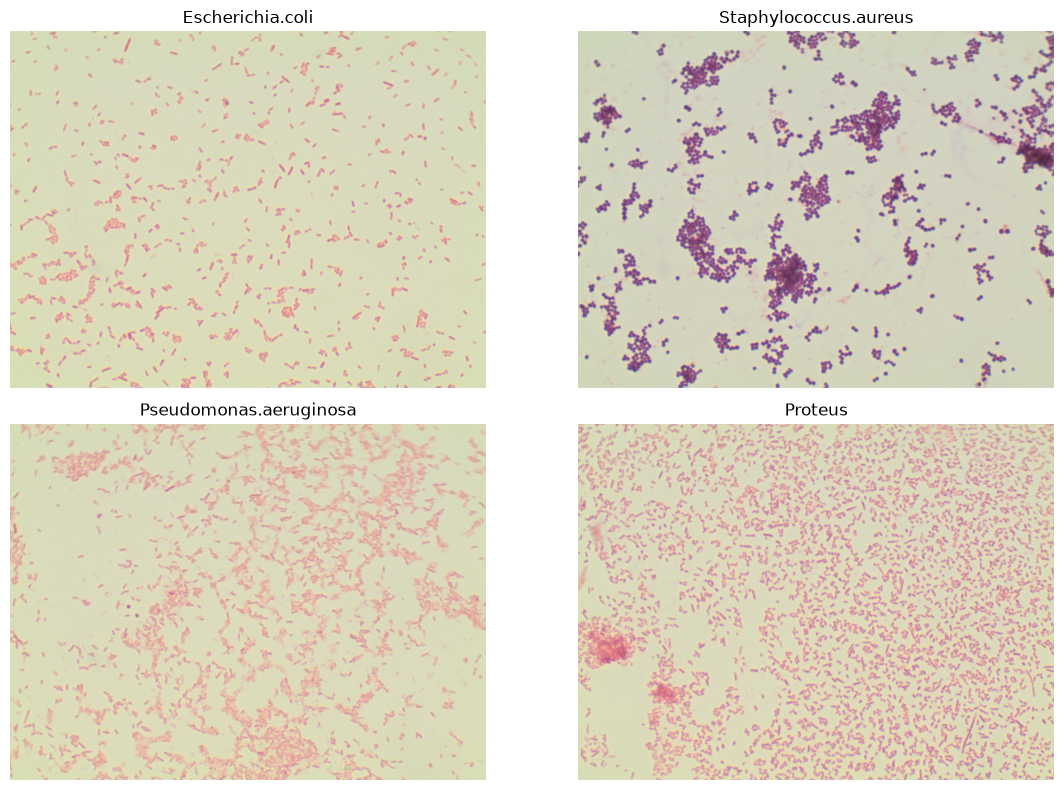

Sample species visualization saved successfully.


In [6]:
# ============================================================
# Stage 3: Sample Images Visualization
#
# Purpose:
# Display sample microbial images from different species
# to visually inspect the dataset.
# ============================================================

# Import required libraries
import os
from PIL import Image
import matplotlib.pyplot as plt

# Dataset path
# Notebook is inside Notebook/ folder,
# so we move one level up using ..
dataset_path = "../archive"

# Select species for visualization
selected_species = [
    "Escherichia.coli",
    "Staphylococcus.aureus",
    "Pseudomonas.aeruginosa",
    "Proteus"
]

# Create figure
plt.figure(figsize=(12, 8))

# Loop through selected species
for index, species in enumerate(selected_species):

    # Create species folder path
    species_path = os.path.join(dataset_path, species)

    # Variable to store first image path
    image_path = None

    # Search for first TIFF image
    for root, dirs, files in os.walk(species_path):

        for file in files:

            # Select TIFF image
            if file.lower().endswith(".tif"):

                image_path = os.path.join(root, file)
                break

        # Stop searching once image is found
        if image_path:
            break

    # Skip if no image found
    if image_path is None:
        continue

    # Open image
    image = Image.open(image_path)

    # Create subplot
    plt.subplot(2, 2, index + 1)

    # Display image
    plt.imshow(image)

    # Add species name as title
    plt.title(species)

    # Hide axis
    plt.axis("off")

# Adjust spacing
plt.tight_layout()

# Save visualization
plt.savefig(
    "../results/sample_species_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

# Display figure
plt.show()

# Print confirmation
print("Sample species visualization saved successfully.")

## Observation

- Sample microbial images from different species were visualized.
- Images show distinct texture and structural patterns.
- Visual differences suggest that deep learning models may learn species-specific features.
- All displayed images are RGB and have consistent dimensions.

# Image Resolution Analysis

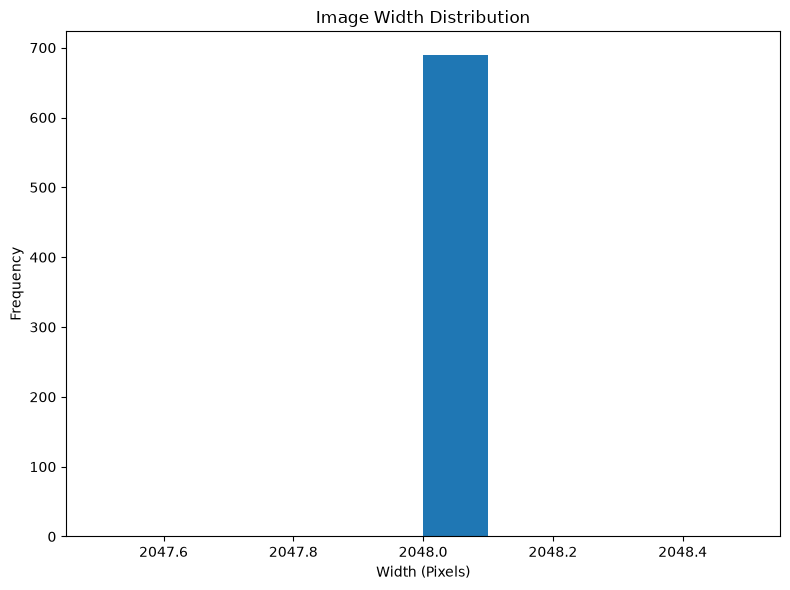

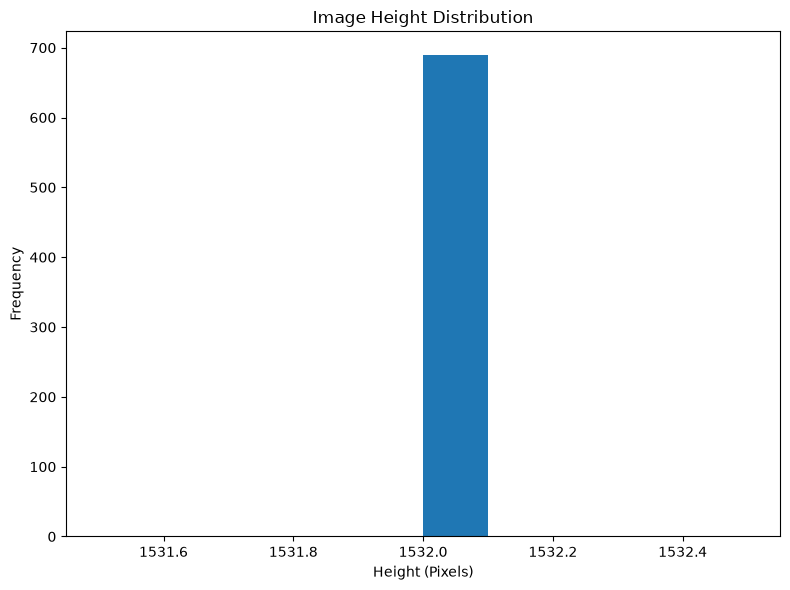

Width Distribution Saved
Height Distribution Saved

Unique Widths Found : {2048}
Unique Heights Found: {1532}

Total Valid Images: 689


In [5]:
# ============================================================
# Stage 3: Image Resolution Visualization
#
# Purpose:
# Analyze image resolutions and verify whether all images
# have the same dimensions.
# ============================================================

# Import required libraries
import os
from PIL import Image
import matplotlib.pyplot as plt

# Dataset path
# Notebook is inside Notebook/ folder,
# so we move one level up using ..
dataset_path = "../archive"

# Store image widths
widths = []

# Store image heights
heights = []

# Traverse dataset folders
for species in os.listdir(dataset_path):

    # Create complete species folder path
    species_path = os.path.join(dataset_path, species)

    # Skip non-folder items
    if not os.path.isdir(species_path):
        continue

    # Traverse folders recursively
    for root, dirs, files in os.walk(species_path):

        # Check every file
        for file in files:

            # Process only TIFF images
            if file.lower().endswith(".tif"):

                try:

                    # Create complete image path
                    image_path = os.path.join(root, file)

                    # Open image
                    image = Image.open(image_path)

                    # Extract width and height
                    width, height = image.size

                    # Store values
                    widths.append(width)
                    heights.append(height)

                except Exception:

                    # Skip corrupted images
                    continue

# ============================================================
# Width Distribution Graph
# ============================================================

# Create figure
plt.figure(figsize=(8, 6))

# Plot width histogram
plt.hist(widths, bins=10)

# Add title
plt.title("Image Width Distribution")

# Add axis labels
plt.xlabel("Width (Pixels)")
plt.ylabel("Frequency")

# Improve layout
plt.tight_layout()

# Save graph
plt.savefig(
    "../results/image_width_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Display graph
plt.show()

# ============================================================
# Height Distribution Graph
# ============================================================

# Create figure
plt.figure(figsize=(8, 6))

# Plot height histogram
plt.hist(heights, bins=10)

# Add title
plt.title("Image Height Distribution")

# Add axis labels
plt.xlabel("Height (Pixels)")
plt.ylabel("Frequency")

# Improve layout
plt.tight_layout()

# Save graph
plt.savefig(
    "../results/image_height_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Display graph
plt.show()

# ============================================================
# Dataset Resolution Summary
# ============================================================

print("Width Distribution Saved")
print("Height Distribution Saved")

print("\nUnique Widths Found :", set(widths))
print("Unique Heights Found:", set(heights))

print("\nTotal Valid Images:", len(widths))

## Observation

- The dataset contains 33 microbial species.
- Total images available: 692.
- Most classes contain between 20 and 23 images.
- The dataset is relatively balanced.
- No major class imbalance was observed.

# Dataset Summary Table


In [7]:
# ============================================================
# Stage 3: Dataset Summary Table
#
# Purpose:
# Display important dataset statistics in tabular form.
# ============================================================

# Import pandas library
import pandas as pd

# Create summary data
summary_data = {
    "Metric": [
        "Total Classes",
        "Total Images",
        "Image Resolution",
        "Image Mode",
        "Corrupted Images"
    ],
    "Value": [
        33,
        692,
        "2048 x 1532",
        "RGB",
        3
    ]
}

# Create DataFrame
summary_table = pd.DataFrame(summary_data)

# Display table
summary_table

,Metric,Value
0,Total Classes,33
1,Total Images,692
2,Image Resolution,2048 x 1532
3,Image Mode,RGB
4,Corrupted Images,3


## Observation

The dataset contains 33 microbial species and 692 images.

All valid images have identical dimensions and RGB format.

Only three corrupted images were identified during exploration.

# Stage 3 Conclusion

The dataset was successfully visualized and analyzed.

Key Findings:

- Dataset contains 33 microbial species.
- Total images available: 692.
- Images are RGB format.
- Resolution is consistent (2048 × 1532).
- Dataset is balanced across classes.
- Only three corrupted images were found.

Conclusion:

The dataset is ready for preprocessing and deep learning model development.